In [7]:
from google.colab import files
uploaded = files.upload()

# This shows you exactly what filename Colab received
print("Files uploaded:", list(uploaded.keys()))

Saving antibiotic_resistance(Sheet1) (2).csv to antibiotic_resistance(Sheet1) (2) (1).csv
Files uploaded: ['antibiotic_resistance(Sheet1) (2) (1).csv']


Species after cleaning: ['Coliform bacteria', 'E. coli', 'Enterobacter cloacae', 'Enterococcus spp', 'Gonorrhea spp', 'Klebsiella spp', 'Staphylococcus spp', 'Streptococcus spp']
Unique species count: 8

Long format records: 380
Species in long_df: ['Coliform bacteria', 'E. coli', 'Enterobacter cloacae', 'Enterococcus spp', 'Gonorrhea spp', 'Klebsiella spp', 'Staphylococcus spp', 'Streptococcus spp']
Unique species in long_df: 8

Species in sp_summary (8):
    bacterial_specie  resistance_rate_%
    Enterococcus spp               68.9
   Coliform bacteria               65.0
Enterobacter cloacae               63.6
       Gonorrhea spp               62.5
   Streptococcus spp               62.5
  Staphylococcus spp               59.1
             E. coli               54.5
      Klebsiella spp               52.5


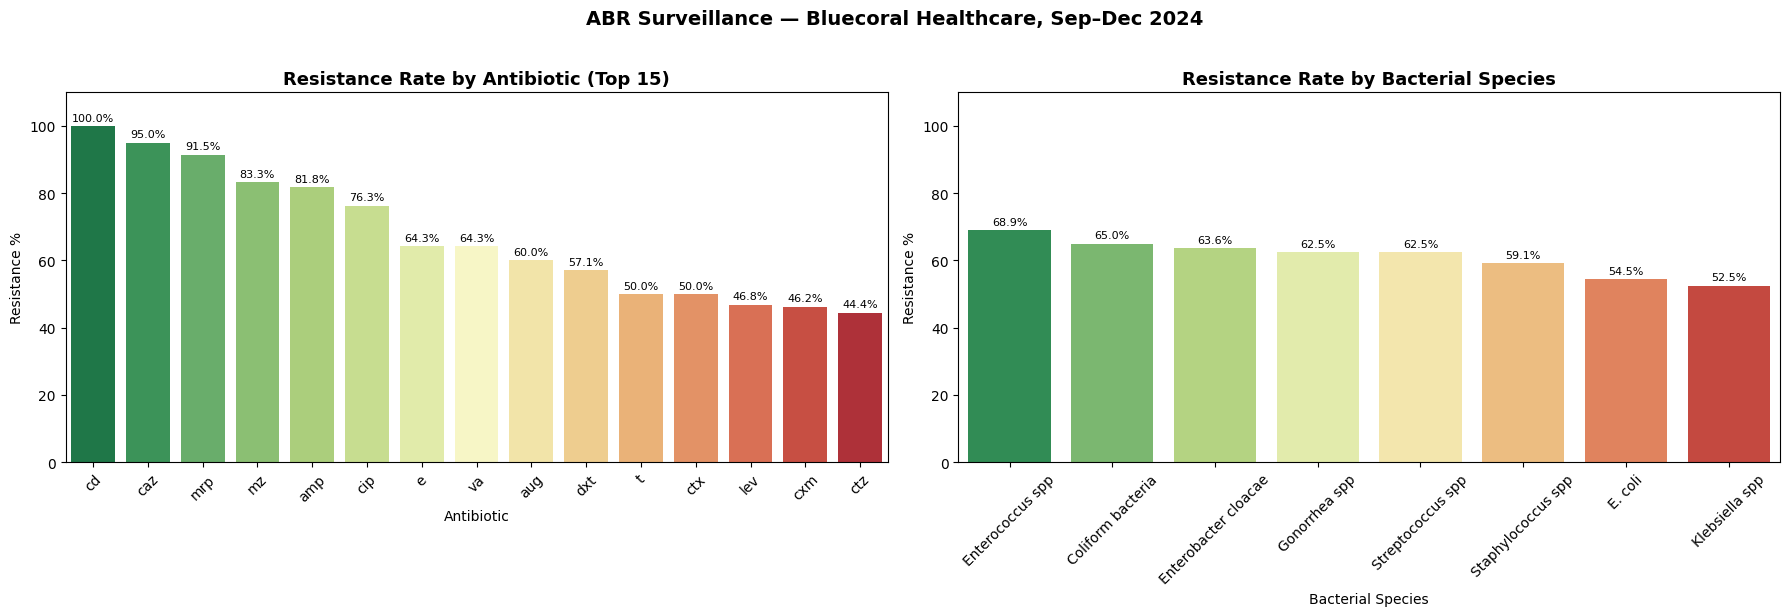


Done


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 1: LOAD ──────────────────────────────────────────
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# ── STEP 2: CLEAN ─────────────────────────────────────────
SPECIES_MAP = {
    "e coli": "E. coli",
    "e. coli": "E. coli",
    # All Staph consolidated
    "staph spp": "Staphylococcus spp",
    "staph  spp": "Staphylococcus spp",
    "staphylococcus spp": "Staphylococcus spp",
    "staph aureus": "Staphylococcus spp",
    "staphylococcus aureus": "Staphylococcus spp",
    "staph saprophyticus": "Staphylococcus spp",
    "staphylococcus saprophyticus": "Staphylococcus spp",
    # All Klebsiella consolidated
    "klebsiella pneumoniae": "Klebsiella spp",
    "klebsiella spp": "Klebsiella spp",
    # All Strep consolidated
    "streptococcus spp": "Streptococcus spp",
    "hemolytic streptococci": "Streptococcus spp",
    # Others
    "enterococcus spp": "Enterococcus spp",
    "enterobacter cloacae": "Enterobacter cloacae",
    "coliform bacteria": "Coliform bacteria",
    "gonnorrhea spp": "Gonorrhea spp",
    "gonorrhea spp": "Gonorrhea spp",
}

df_clean = df.copy()
df_clean['bacterial_specie'] = (
    df_clean['bacterial_specie']
    .str.strip().str.lower()
    .map(lambda x: SPECIES_MAP.get(x, x.title()))
)
for col in ['antibiotic_tested', 'sensitivity_result', 'resistant_result']:
    df_clean[col] = df_clean[col].str.strip().str.lower()
df_clean['gender'] = df_clean['gender'].str.strip().str.lower()
df_clean['sample'] = df_clean['sample'].str.strip().str.lower()

print("Species after cleaning:", sorted(df_clean['bacterial_specie'].unique()))
print(f"Unique species count: {df_clean['bacterial_specie'].nunique()}")

# ── STEP 3: TRANSFORM ─────────────────────────────────────
records = []
for _, row in df_clean.iterrows():
    tested = [a.strip() for a in str(row['antibiotic_tested']).split(',')]
    resistant = [a.strip() for a in str(row['resistant_result']).split(',')]
    for ab in tested:
        if ab and ab != 'nan':
            records.append({
                'sample_id': row['sample_id'],
                'date': row['date'],
                'bacterial_specie': row['bacterial_specie'],
                'sample_type': row['sample'],
                'age': row['age'],
                'gender': row['gender'],
                'antibiotic': ab,
                'resistant': 1 if ab in resistant else 0
            })

long_df = pd.DataFrame(records)
print(f"\nLong format records: {len(long_df)}")
print(f"Species in long_df: {sorted(long_df['bacterial_specie'].unique())}")
print(f"Unique species in long_df: {long_df['bacterial_specie'].nunique()}")

# Resistance by antibiotic
ab_summary = long_df.groupby('antibiotic').agg(
    total_tested=('resistant','count'),
    total_resistant=('resistant','sum')
).reset_index()
ab_summary['resistance_rate_%'] = (
    ab_summary['total_resistant'] / ab_summary['total_tested'] * 100
).round(1)
ab_summary = ab_summary.sort_values('resistance_rate_%', ascending=False)

# Resistance by species — fresh from long_df
sp_summary = long_df.groupby('bacterial_specie').agg(
    total_tested=('resistant','count'),
    total_resistant=('resistant','sum')
).reset_index()
sp_summary['resistance_rate_%'] = (
    sp_summary['total_resistant'] / sp_summary['total_tested'] * 100
).round(1)
sp_summary = sp_summary.sort_values('resistance_rate_%', ascending=False)

print(f"\nSpecies in sp_summary ({len(sp_summary)}):")
print(sp_summary[['bacterial_specie','resistance_rate_%']].to_string(index=False))

# ── STEP 4: VISUALIZE ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=ab_summary.head(15), x='antibiotic', y='resistance_rate_%',
            hue='antibiotic', palette='RdYlGn_r', legend=False, ax=axes[0])
axes[0].set_title("Resistance Rate by Antibiotic (Top 15)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Resistance %")
axes[0].set_xlabel("Antibiotic")
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[0].patches, ab_summary.head(15)['resistance_rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}%", ha='center', va='bottom', fontsize=8)

sns.barplot(data=sp_summary, x='bacterial_specie', y='resistance_rate_%',
            hue='bacterial_specie', palette='RdYlGn_r', legend=False, ax=axes[1])
axes[1].set_title("Resistance Rate by Bacterial Species", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Resistance %")
axes[1].set_xlabel("Bacterial Species")
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(axes[1].patches, sp_summary['resistance_rate_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}%", ha='center', va='bottom', fontsize=8)

plt.suptitle("ABR Surveillance — Bluecoral Healthcare, Sep–Dec 2024",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("abr_charts_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nDone")